In [5]:
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from shapely.geometry import mapping

In [3]:
gdf = gpd.read_file('./data/geoz.stzh_hk_geschlossen.shp')
gdf.head()

,objectid,hoehe,klasse,geometry
0,462.0,694.0,2.0,"LINESTRING Z (2688387.710 1245927.375 694.000,..."
1,110.0,682.0,2.0,"LINESTRING Z (2688343.687 1245864.888 682.000,..."
2,415.0,622.0,2.0,"LINESTRING Z (2688192.491 1246668.215 622.000,..."
3,216.0,610.0,10.0,"LINESTRING Z (2689590.152 1246466.939 610.000,..."
4,32.0,612.0,2.0,"LINESTRING Z (2689356.625 1246579.040 612.000,..."


In [6]:
transform = rasterio.transform.from_origin(west=gdf.total_bounds[0], north=gdf.total_bounds[3], xsize=1, ysize=1)
out_shape = (int((gdf.total_bounds[3] - gdf.total_bounds[1]) / 1), int((gdf.total_bounds[2] - gdf.total_bounds[0]) / 1))

In [7]:
raster = rasterize(
    [(mapping(geom), 1) for geom in gdf.geometry],
    out_shape=out_shape,
    transform=transform,
    fill=0,
    all_touched=True,
    dtype=rasterio.uint8
)

In [12]:
with rasterio.open(
        'raster.tif',
        'w',
        driver='GTiff',
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=rasterio.uint8,
        crs=gdf.crs,
        transform=transform,
) as dst:
    dst.write(raster, 1)

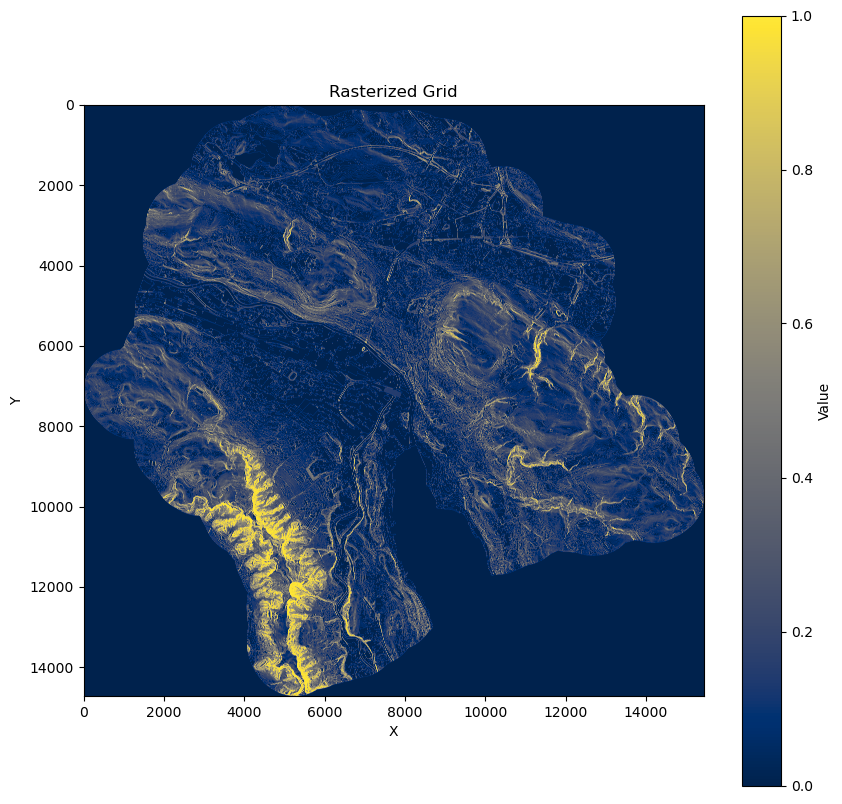

In [11]:
import matplotlib.pyplot as plt
import rasterio

# Read the raster data
with rasterio.open('raster.tif') as src:
    raster = src.read(1)

# Plot the raster data
plt.figure(figsize=(10, 10))
plt.imshow(raster, cmap='cividis')
plt.colorbar(label='Value')
plt.title('Rasterized Grid')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()